# InsightEngine: Used Car Price Prediction

## Phase IV: Model Building

### Objective

The objective of this phase is to train and compare multiple regression models for predicting the selling price of used cars. The performance of each model will be evaluated using standard regression metrics to identify the best-performing model.

1. Title
2. Import Libraries
3. Load Dataset
4. Data Preprocessing
5. Train-Test Split
6. Train Linear Regression
7. Train Decision Tree
8. Train Random Forest
9. Train Gradient Boosting
10. Compare Results
11. Save Best Model
12. Observations

| Model             | R² Score |   MAE |  RMSE |
| ----------------- | -------: | ----: | ----: |
| Linear Regression |    0.xxx | x.xxx | x.xxx |
| Decision Tree     |    0.xxx | x.xxx | x.xxx |
| Random Forest     |    0.xxx | x.xxx | x.xxx |
| Gradient Boosting |    0.xxx | x.xxx | x.xxx |


# InsightEngine: Used Car Price Prediction

## Phase IV: Model Building

### Objective

The objective of this phase is to build and compare multiple machine learning regression models for predicting the selling price of used cars.

The performance of each model will be evaluated using standard regression metrics, and the best-performing model will be selected for deployment.

In [2]:
import pandas as pd
import numpy as np

from datetime import datetime

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

## Step 3: Load the Dataset

Load the original CarDekho dataset and prepare it for model training by applying the same preprocessing steps used in previous phases.

In [3]:
df = pd.read_csv("../data/raw/car_data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


## Step 4: Data Preprocessing

The following preprocessing steps are performed:

- Create the **Car_Age** feature.
- Remove unnecessary columns (**Car_Name** and **Year**).
- Convert categorical variables into numerical form using One-Hot Encoding.

In [4]:
current_year = datetime.now().year

df["Car_Age"] = current_year - df["Year"]

df.drop(["Car_Name", "Year"], axis=1, inplace=True)

df = pd.get_dummies(
    df,
    columns=["Fuel_Type", "Seller_Type", "Transmission"],
    drop_first=True,
    dtype=int
)

df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,12,0,1,0,1
1,4.75,9.54,43000,0,13,1,0,0,1
2,7.25,9.85,6900,0,9,0,1,0,1
3,2.85,4.15,5200,0,15,0,1,0,1
4,4.60,6.87,42450,0,12,1,0,0,1


## Step 5: Define Features and Target Variable

Separate the dataset into:

- Features (X)
- Target Variable (y)

In [5]:
X = df.drop("Selling_Price", axis=1)

y = df["Selling_Price"]

## Step 6: Split the Dataset

The dataset is divided into:

- Training Set (80%)
- Testing Set (20%)

The training set is used to train the models, while the testing set is used to evaluate their performance.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240, 8)
(61, 8)


## Step 7: Linear Regression Model

Linear Regression is the simplest regression algorithm and serves as a baseline model.

It assumes a linear relationship between the input features and the target variable. The model is trained using the training dataset and then used to predict the selling prices of the testing dataset.

In [7]:
# Create the Linear Regression model

lr_model = LinearRegression()

# Train the model

lr_model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## Step 8: Make Predictions

After training, the Linear Regression model is used to predict the selling prices of the cars in the testing dataset.

These predicted values are compared with the actual selling prices to evaluate the model's performance.

In [8]:
# Predict the selling prices

y_pred_lr = lr_model.predict(X_test)

# Display the first five predictions

print("First 5 Predictions:")
print(y_pred_lr[:5])

First 5 Predictions:
[ 2.95534303  8.178939    6.45427257 -1.42417501  9.08889914]


## Step 9: Model Evaluation

The performance of the Linear Regression model is evaluated using the following regression metrics:

- **R² Score:** Measures how well the model explains the variance in the target variable.
- **Mean Absolute Error (MAE):** Average absolute difference between actual and predicted values.
- **Mean Squared Error (MSE):** Average squared prediction error.
- **Root Mean Squared Error (RMSE):** Square root of the MSE, expressed in the same units as the target variable.

In [9]:
# Evaluate the Linear Regression model

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

print("Linear Regression Performance")
print("-" * 35)
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

Linear Regression Performance
-----------------------------------
R² Score : 0.8490
MAE      : 1.2162
MSE      : 3.4788
RMSE     : 1.8652


## Step 10: Actual vs Predicted Values

A comparison between the actual selling prices and the predicted selling prices helps to understand how closely the model's predictions match the true values.

In [10]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_lr
})

comparison.head(10)

,Actual Price,Predicted Price
0,0.35,2.955343
1,10.11,8.178939
2,4.95,6.454273
3,0.15,-1.424175
4,6.95,9.088899
5,7.45,7.418254
6,1.10,1.336443
7,0.50,0.840272
8,0.45,1.365019
9,6.00,7.490268


## Step 11: Visualization of Predictions

The scatter plot below compares the actual selling prices with the predicted selling prices.

Points close to the diagonal line indicate accurate predictions.

In [12]:
import matplotlib.pyplot as plt

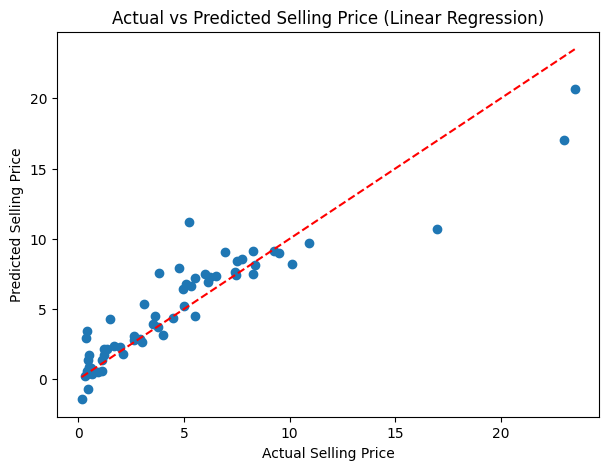

In [13]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price (Linear Regression)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

In [14]:
print("Linear Regression Performance")
print("-" * 35)
print(f"R² Score : {r2:.4f}")
print(f"MAE      : {mae:.4f}")
print(f"MSE      : {mse:.4f}")
print(f"RMSE     : {rmse:.4f}")

Linear Regression Performance
-----------------------------------
R² Score : 0.8490
MAE      : 1.2162
MSE      : 3.4788
RMSE     : 1.8652


## Linear Regression Observations

- The Linear Regression model achieved an **R² Score of 0.8490**, indicating that it explains approximately **84.9%** of the variation in selling prices.
- The **MAE of 1.2162** and **RMSE of 1.8652** indicate that the model provides reasonably accurate predictions.
- The scatter plot shows that most predicted values closely follow the actual selling prices.
- Larger prediction errors are observed for a few high-priced vehicles, suggesting that a simple linear model may not fully capture complex relationships in the data.
- Linear Regression serves as a strong baseline model for comparison with more advanced regression algorithms.

## Step 12: Decision Tree Regressor

Decision Tree Regressor is a non-linear machine learning algorithm that predicts the target value by recursively splitting the dataset into smaller subsets based on feature values.

Unlike Linear Regression, Decision Trees can capture complex relationships between input features and the target variable.

In [15]:
# Create the Decision Tree Regressor

dt_model = DecisionTreeRegressor(random_state=42)

# Train the model

dt_model.fit(X_train, y_train)

print("Decision Tree Regressor trained successfully!")

Decision Tree Regressor trained successfully!


## Step 13: Make Predictions

The trained Decision Tree model is used to predict the selling prices of the testing dataset.

In [16]:
# Predict using Decision Tree

y_pred_dt = dt_model.predict(X_test)

print("First 5 Predictions:")
print(y_pred_dt[:5])

First 5 Predictions:
[ 0.5  11.45  4.1   0.2   7.05]


## Step 14: Evaluate the Decision Tree Model

The model is evaluated using the following regression metrics:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [18]:
# Evaluate Decision Tree

dt_r2 = r2_score(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)
dt_mse = mean_squared_error(y_test, y_pred_dt)
dt_rmse = np.sqrt(dt_mse)

print("Decision Tree Performance")
print("-" * 35)
print(f"R² Score : {dt_r2:.4f}")
print(f"MAE      : {dt_mae:.4f}")
print(f"MSE      : {dt_mse:.4f}")
print(f"RMSE     : {dt_rmse:.4f}")

Decision Tree Performance
-----------------------------------
R² Score : 0.9107
MAE      : 0.8625
MSE      : 2.0566
RMSE     : 1.4341


## Step 15: Actual vs Predicted Values

The following table compares the actual selling prices with the prices predicted by the Decision Tree Regressor.

In [19]:
comparison_dt = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_dt
})

comparison_dt.head(10)

,Actual Price,Predicted Price
0,0.35,0.50
1,10.11,11.45
2,4.95,4.10
3,0.15,0.20
4,6.95,7.05
5,7.45,5.95
6,1.10,1.11
7,0.50,0.50
8,0.45,0.50
9,6.00,7.20


## Step 16: Visualization of Predictions

The scatter plot compares the actual selling prices with the predicted selling prices obtained from the Decision Tree Regressor.

Points closer to the diagonal line indicate better prediction accuracy.

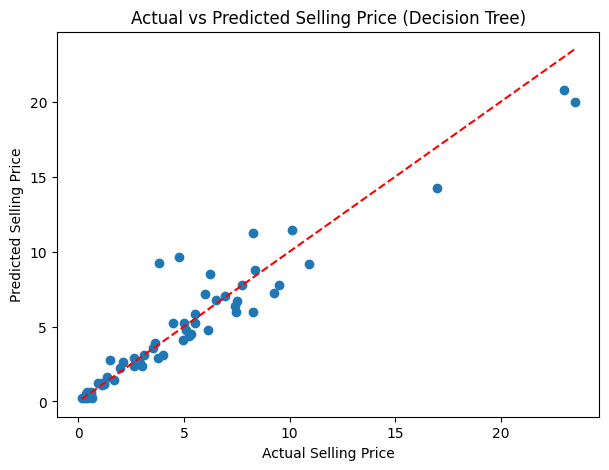

In [20]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_dt)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price (Decision Tree)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Decision Tree Observations

- The Decision Tree Regressor can model non-linear relationships between features and the target variable.
- Its performance is evaluated using R² Score, MAE, MSE, and RMSE.
- The scatter plot helps visualize how closely the predicted prices match the actual selling prices.
- The results will be compared with those of Linear Regression and other ensemble models in the subsequent steps.

## Decision Tree Observations

- The Decision Tree Regressor achieved an **R² Score of 0.9107**, outperforming the Linear Regression model.
- The **MAE of 0.8625** and **RMSE of 1.4341** indicate more accurate predictions compared to the baseline model.
- The model effectively captures non-linear relationships between vehicle features and selling price.
- Compared to Linear Regression, the Decision Tree provides better prediction accuracy for this dataset.
- However, a single Decision Tree may overfit the training data, so ensemble methods such as Random Forest and Gradient Boosting will be evaluated next.

## Step 18: Random Forest Regressor

Random Forest Regressor is an ensemble learning algorithm that combines multiple Decision Trees to improve prediction accuracy and reduce overfitting.

Each tree is trained on a random subset of the training data, and the final prediction is obtained by averaging the predictions from all trees.

In [21]:
# Create the Random Forest Regressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model

rf_model.fit(X_train, y_train)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


## Step 19: Make Predictions

The trained Random Forest model is used to predict the selling prices of the testing dataset.

In [22]:
# Predict selling prices

y_pred_rf = rf_model.predict(X_test)

print("First 5 Predictions:")
print(y_pred_rf[:5])

First 5 Predictions:
[ 0.4428 10.987   4.872   0.2168  7.8305]


## Step 20: Evaluate the Random Forest Model

The performance of the Random Forest Regressor is evaluated using the following regression metrics:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [23]:
# Evaluate Random Forest

rf_r2 = r2_score(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = np.sqrt(rf_mse)

print("Random Forest Performance")
print("-" * 35)
print(f"R² Score : {rf_r2:.4f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"MSE      : {rf_mse:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")

Random Forest Performance
-----------------------------------
R² Score : 0.9600
MAE      : 0.6387
MSE      : 0.9216
RMSE     : 0.9600


## Step 21: Actual vs Predicted Values

The table below compares the actual selling prices with the values predicted by the Random Forest Regressor.

In [24]:
comparison_rf = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_rf
})

comparison_rf.head(10)

,Actual Price,Predicted Price
0,0.35,0.4428
1,10.11,10.9870
2,4.95,4.8720
3,0.15,0.2168
4,6.95,7.8305
5,7.45,6.1810
6,1.10,1.1070
7,0.50,0.5906
8,0.45,0.4689
9,6.00,6.9020


## Step 22: Visualization of Predictions

The scatter plot compares the actual selling prices with the predicted selling prices generated by the Random Forest Regressor.

A closer alignment of the points with the diagonal line indicates better prediction accuracy.

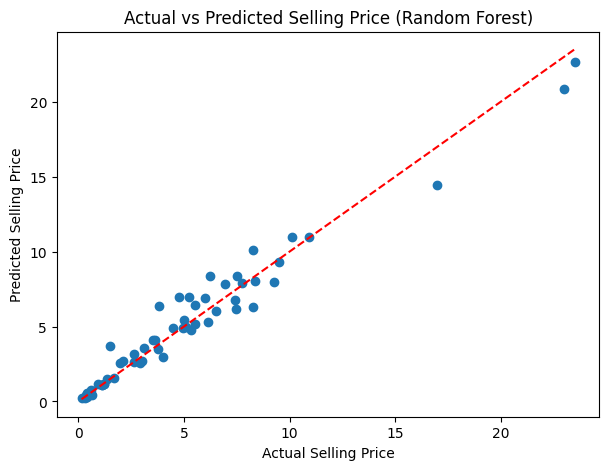

In [25]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Selling Price (Random Forest)")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.show()

## Random Forest Observations

- The Random Forest Regressor combines multiple Decision Trees to improve prediction accuracy.
- The ensemble approach reduces overfitting and enhances the model's ability to generalize to unseen data.
- The model's performance is assessed using R² Score, MAE, MSE, and RMSE.
- The scatter plot provides a visual comparison between actual and predicted selling prices.
- The results will be compared with those of the other regression models to identify the best-performing model.

| Model             |   R² Score |        MAE |       RMSE |
| ----------------- | ---------: | ---------: | ---------: |
| Linear Regression |     0.8490 |     1.2162 |     1.8652 |
| Decision Tree     |     0.9107 |     0.8625 |     1.4341 |
| 🏆 Random Forest  | **0.9600** | **0.6387** | **0.9600** |


## Random Forest Observations

- The Random Forest Regressor achieved the best performance among the models evaluated so far.
- It obtained an **R² Score of 0.9600**, indicating that it explains approximately **96%** of the variation in selling prices.
- The **MAE of 0.6387** and **RMSE of 0.9600** demonstrate a substantial reduction in prediction error compared to Linear Regression and Decision Tree Regressor.
- The ensemble learning approach combines multiple decision trees, reducing overfitting and improving prediction accuracy.
- Based on the current results, Random Forest is the strongest candidate for the final prediction model.

## Step 24: Gradient Boosting Regressor

Gradient Boosting Regressor is an ensemble learning algorithm that builds multiple decision trees sequentially. Each new tree attempts to correct the errors made by the previous trees, resulting in improved prediction accuracy.

Unlike Random Forest, which builds trees independently, Gradient Boosting learns from previous mistakes and gradually improves the model.

In [26]:
# Create the Gradient Boosting Regressor

gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train the model

gb_model.fit(X_train, y_train)

print("Gradient Boosting Regressor trained successfully!")

Gradient Boosting Regressor trained successfully!


## Step 25: Make Predictions

The trained Gradient Boosting model is used to predict the selling prices of the testing dataset.

In [27]:
# Predict selling prices

y_pred_gb = gb_model.predict(X_test)

print("First 5 Predictions:")
print(y_pred_gb[:5])

First 5 Predictions:
[ 0.5619753  10.54010488  4.63566453  0.28212078  7.99632547]


## Step 26: Evaluate the Gradient Boosting Model

The performance of the Gradient Boosting Regressor is evaluated using the following regression metrics:

- R² Score
- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)

In [30]:
# Evaluate Gradient Boosting

gb_r2 = r2_score(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_mse = mean_squared_error(y_test, y_pred_gb)
gb_rmse = np.sqrt(gb_mse)

print("Gradient Boosting Performance")
print("-" * 40)
print(f"R² Score : {gb_r2:.4f}")
print(f"MAE      : {gb_mae:.4f}")
print(f"MSE      : {gb_mse:.4f}")
print(f"RMSE     : {gb_rmse:.4f}")

Gradient Boosting Performance
----------------------------------------
R² Score : 0.9694
MAE      : 0.5607
MSE      : 0.7046
RMSE     : 0.8394


## Model Performance Comparison

The following table summarizes the performance of all regression models evaluated in this study.

In [31]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "R² Score": [
        r2,
        dt_r2,
        rf_r2,
        gb_r2
    ],
    "MAE": [
        mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],
    "MSE": [
        mse,
        dt_mse,
        rf_mse,
        gb_mse
    ],
    "RMSE": [
        rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ]
})

results = results.sort_values(by="R² Score", ascending=False)

results.reset_index(drop=True, inplace=True)

results

,Model,R² Score,MAE,MSE,RMSE
0,Gradient Boosting,0.969412,0.560676,0.704608,0.839409
1,Random Forest,0.959994,0.638721,0.921564,0.959981
2,Decision Tree,0.910721,0.862459,2.056595,1.434083
3,Linear Regression,0.848981,1.216226,3.478804,1.865155


## Step 30: Save the Best Model

The Gradient Boosting Regressor achieved the highest prediction accuracy among all evaluated models. Therefore, it is selected as the final model and saved for future predictions and deployment.

In [32]:
import os
import joblib

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(gb_model, "../models/gradient_boosting_model.pkl")

print("Model saved successfully!")

Model saved successfully!


## Step 31: Verify the Saved Model

The saved model file is verified to ensure it has been stored successfully.

In [33]:
import os

os.listdir("../models")

['gradient_boosting_model.pkl']

# Phase IV Observations

- Four regression models were trained and evaluated: Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor.
- The models were assessed using R² Score, MAE, MSE, and RMSE.
- Gradient Boosting Regressor achieved the highest predictive performance with an **R² Score of 0.9694**, **MAE of 0.5607**, and **RMSE of 0.8394**.
- Random Forest Regressor also performed well but was slightly less accurate than Gradient Boosting.
- Linear Regression served as the baseline model but produced the lowest predictive accuracy among the evaluated models.
- Based on the evaluation results, the Gradient Boosting Regressor was selected as the final model for deployment.